# [LAB-11] 시계열 분석ㅣ05-ARIMA 모델링(실습코드).ipynb

## ARIMA(자기회귀누적이동평균) 개요

**과거의 데이터와 오차를 사용하여 미래의 값을 예측하는 대표적 시계열 통계 모델**

$$AR + I + MA = ARIMA(p, d, q)$$

| 구성요소 | 이름·차수 | 한 줄 요약 |
|---|---|---|
| AR | AutoRegressive · p | 과거의 **값**으로 현재를 설명 |
| I | Integrated · d | **차분**으로 정상성을 확보 → 원본 데이터를 전달하면 모형이 직접 차분을 수행한다 |
| MA | Moving Average · q | 과거의 **오차**로 현재를 설명 |

### 1~4단원이 진행되는 동안 air_passengers 데이터에서 확인된 내용

| 단원 | 확인된 내용 |
|---|---|
| 1단원 | 로그변환 여부 판단 / 일반 차분 1회(d=1) / 계절 차분 1회, 12주기(D=1·s=12), ADF p-value < 0.05 → 정상 |
| 2단원 | 계절 주기 12 확인 |
| 3단원 | 승법 결합·계절지수 7월 최대(1.227)·11월 최소(0.801) → 로그변환 필요성 확인 |
| 4단원 | p≤1·q≤1·P≤1·Q≤1 |
| 5단원(이번) | 모형 적합·진단·예측 |

---

## AR과 MA 비교

### AR(p)
**과거의 값을 이용해 미래를 예측**

$$y_t = c + \varphi_1 y_{t-1} + \cdots + \varphi_p y_{t-p} + \varepsilon_t$$

- **사고방식**: "1월에 500명이었으니 2월도 그 근처겠지" → 값 자체의 관성을 이어간다
- **의미**
  - p=1 → "직전 값 하나만 본다"
  - p=2 → "직전 값 두 개를 본다"
- **어울리는 상황**: 값 자체가 관성을 가짐 (기온·재고 수준)
- **차수 판정**: p는 PACF로 판정 (4단원)

### MA(q)
**과거의 오차를 이용해 미래를 예측**

$$y_t = c + \varepsilon_t + \theta_1 \varepsilon_{t-1} + \cdots + \theta_q \varepsilon_{t-q}$$

- **사고방식**: "1월에 20명 적게 예측했으니 2월 예측을 그만큼 조정하자" → 예측 실수를 보정한다
- **의미**
  - q=1 → "직전 오차 하나만 본다"
  - q=2 → "직전 오차 두 개를 본다"
- **어울리는 상황**: 일시적 충격이 잠깐 영향 (파업·이벤트)
- **차수 판정**: q는 ACF로 판정 (4단원)

**공통**: 실제 모형은 둘을 함께 쓴다. ARIMA(p, d, q)에서 p는 값의 기억, q는 오차의 기억, d는 차분 횟수다.

---

## SARIMA 모형

### Seasonal + ARIMA
계절 전용 세트를 따로 두어 계수 4개로 "작년 같은 달"을 표현한다.

$$SARIMA(p, d, q)(P, D, Q)s$$

| 구분 | 성분 | 무엇을 보는가 |
|---|---|---|
| 비계절 | (p, d, q) | 지난달·지지난달 |
| 계절 | (P, D, Q)s | 작년 같은 달·재작년 같은 달 |

### 비계절 성분과 계절 성분 차이

| 구분 | AR — 값을 본다 | MA — 오차를 본다 |
|---|---|---|
| 비계절 | 최근에 내가 어땠는지 | 최근에 얼마나 틀렸는지 |
| 계절 | 예전 같은 계절에 어땠는지 | 예전 같은 계절에 얼마나 틀렸는지 |

In [14]:
from jussam import load_data
from helpers import *

from pandas import DataFrame, Series
import numpy as np
import pandas as pd

# 차수 조합을 만들기 위한 도구
from itertools import product

# ARIMA · SARIMA 모형
from statsmodels.tsa.statespace.sarimax import SARIMAX

# 차수 조합을 여러 개 적합하면 수렴 경고가 반복 출력되므로 경고를 숨긴다
import warnings
warnings.filterwarnings("ignore")

### 2. 데이터 가져오기 및 인덱스 설정 

In [15]:
origin = load_data('air_passengers')

df = my_ts.set_index(origin, "Month", freq="MS")

print(f"데이터셋 크기: {df.shape[0]}행")
print(f"기간: {df.index[0]:%Y-%m} ~ {df.index[-1]:%Y-%m}")

df.head()

📚 어느 항공사의 월간 탑승객 수 (출처: https://www.kaggle.com/datasets/rakannimer/air-passengers)
데이터셋 크기: 144행
기간: 1949-01 ~ 1960-12


,Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


### 3. 1~4 단원에서 확정한 파라미터 

In [16]:
d = 1 # 1단원 : 일반차분 1회 
D = 1 # 1단원 : 계절차분 1회 
s = 12 # 1, 2, 3단원 : 계절 주기 
p = 1 # 4단원 : AR(1) 모형 
q = 1 # 4단원 : MA(1) 모형 
P = 1 # 4단원 : 계절 AR(1) 모형
Q = 1 # 4단원 : 계절 MA(1) 모형 

print(f"p 상한={p}, 차분 d={d}, q 상한={q}")
print(f"P 상한={P}, 계절차분 D={D}, Q 상한={Q}, 계절주기 s={s}")
print(f"모형 차수: ARIMA({p},{d},{q}) x ({P},{D},{Q})_{s}")

p 상한=1, 차분 d=1, q 상한=1
P 상한=1, 계절차분 D=1, Q 상한=1, 계절주기 s=12
모형 차수: ARIMA(1,1,1) x (1,1,1)_12


## #02. ARIMA 모형 적합 
### 1. 모형에 넣을 데이터 만들기 
로그만 취하고 차분은 하지 않는다. 

In [17]:
log_s = np.log(df["Passengers"])
log_s.name = "log_Pasengers"
log_s.head()

Month
1949-01-01   4.718
1949-02-01   4.771
1949-03-01   4.883
1949-04-01   4.860
1949-05-01   4.796
Freq: MS, Name: log_Pasengers, dtype: float64

### 2. 모형 적합 

In [18]:
# 차수는 1~4 단원이 인계한 값을 그대로 쓴다 
model = SARIMAX(log_s, order=(0, d, 1), seasonal_order=(0, D, 1, s))

# disp = False로 지정하면 적합 과정에서 반복되는 로그 메시지를 숨긴다 
fit = model.fit(disp=False) 

print(fit.summary())

                                     SARIMAX Results                                      
Dep. Variable:                      log_Pasengers   No. Observations:                  144
Model:             SARIMAX(0, 1, 1)x(0, 1, 1, 12)   Log Likelihood                 244.696
Date:                            Thu, 13 Aug 2026   AIC                           -483.393
Time:                                    17:40:52   BIC                           -474.767
Sample:                                01-01-1949   HQIC                          -479.888
                                     - 12-01-1960                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.4017      0.073     -5.503      0.000      -0.545      -0.259
ma.S.L12      -0.5571      0.096   

## SARIMAX Results 해석

| 번호 | 설명 |
|---|---|
| ① | 관측치 수 |
| ② | 모형간의 비교 지표 |
| ③ | 비계절 MA 1차 - 직전 시점의 예측 오차 |
| ④ | 계절 MA - 12시점 전의 예측 오차 |
| ⑤ | 잔차의 분산 추정치 (모형이 설명하지 못하는 변동의 크기) |
| ⑥ | 가정 확인에 사용되는 지표 (6단원) |
| ⑦ | 잔차 진단 요약 (6단원) |

**모형**: SARIMAX(0, 1, 1)x(0, 1, 1, 12) / **Sample**: 1949-01-01 ~ 1960-12-01

| | coef | std err | z | P>\|z\| |
|---|---|---|---|---|
| ma.L1 | -0.4017 | 0.073 | -5.502 | 0.000 |
| ma.S.L12 | -0.5566 | 0.096 | -5.781 | 0.000 |
| sigma2 | 0.0013 | 0.000 | 9.122 | 0.000 |

Ljung-Box (L1) (Q): 0.04 / Prob(Q): 0.84 / Jarque-Bera (JB): 1.90 / Prob(JB): 0.39 / Heteroskedasticity (H): 0.58 / Prob(H): 0.07

---

### 2. 모형 적합 (결과표 읽는 법)

**계수 이름이 뜻하는 것**

| 계수 이름 | 무엇인가 |
|---|---|
| ar.L1 | 직전 시점의 값 |
| ma.L1 | 직전 시점의 예측 오차 |
| ar.S.L12 | 작년 같은 달의 값 (12는 계절 주기) |
| ma.S.L12 | 작년 같은 달의 예측 오차 (12는 계절 주기) |
| sigma2 | 잔차 분산 추정치 |

**결과표는 위치로 읽는다**

| 위치 | 무엇이 있는가 |
|---|---|
| 좌측 상단 | No. Observations |
| 우측 상단 | AIC · BIC |
| 중앙 | coef · P>\|z\| |
| 하단 | Prob(Q) · Prob(JB) · Prob(H) = 잔차 진단 요약 |

> ⚠️ 실습 예제의 결과표에서 ar.L1과 ar.S.L12는 출력되지 않았다. (모형마다 다름)

### 2. 모형 적합 (인사이트)

**계수 결과표 읽기**

| 변수 | 계수 | 유의확률 | 해석 |
|---|---|---|---|
| ma.L1 | -0.402 | < 0.001 | 지난달 실제가 예측보다 높게 나왔으면 이번 달은 낮춰 잡는다 |
| ma.S.L12 | -0.557 | < 0.001 | 작년 같은 달의 오차를 더 강하게 반영한다 |
| sigma2 | 0.0013 | < 0.001 | 로그 스케일 잔차 분산. 매우 작다 |

**① 부호 → 되돌림(mean reversion)**
- 두 계수 모두 p < 0.001로 강하게 유의하다. 군더더기 없는 모형이다.
- 계수가 음수 → 되돌림(mean reversion). 지난달이 예측보다 높았으면 이번 달은 낮춰 잡고, 낮았으면 높여 잡는다.
- 4단원 정상 시계열 lag 1 상관 -0.341과 같은 이야기다.

> ⚠️ 계수가 양수였다면 정반대로 해석한다. 양수는 "지난달에 튄 방향으로 이번 달도 따라간다"(관성)는 뜻이다. 부호를 보지 않고 해석하면 방향이 반대가 된다.

**② 절댓값 → 계절성이 더 강하다**
- 절댓값: 계절 -0.557 > 비계절 -0.402 → 작년 같은 달 정보가 더 중요하다. 계절성이 강한 데이터의 특징이다.
- 4단원 ACF lag 12(-0.387) > lag 1(-0.341)과 일치. 논으로 읽은 것이 계수로 확인되었다.
- **되돌림(mean reversion)** = 값이 평균에서 벗어나면 다시 평균 쪽으로 돌아오려는 성질

> ⚠️ 아직 이 차수가 최선이라는 근거는 없다. 후보 중 하나를 골랐을 뿐이다.

---

## #모든 경우의 수 조합 후 최적 모델 채택 — AIC와 BIC

**ACF/PACF는 후보를 좁혀줄 뿐 정답을 찍어주지 않는다.**
- p, q, P, Q의 의미는 고정값이 아니라 0부터 시작되는 범위 내의 상한값이다.
  - 4단원의 결론은 "p≤1, q≤1, P≤1, Q≤1"이었다.
- 후보 2×2×2×2=16가지 — 후보를 좁히지 않았다면 수백 가지를 돌려야 했다. 이것이 4단원의 값어치다.

**16가지 모형의 선정 기준 - AIC, BIC**
- 두 지표 모두 "잘 맞출수록 낮아지고, 계수가 많을수록 높아진다".
  - 즉 잘 맞으면서도 단순한 모형에 낮은 값을 준다.

| 지표 | 벌점의 세기 | 고르는 모형 | 언제 쓰는가 |
|---|---|---|---|
| AIC | 벌점이 약함 | 상대적으로 복잡한 모형 | 예측이 목적일 때 |
| BIC | ln(n)만큼 벌점 | 더 단순한 모형 | 설명·해석이 목적일 때 |

> ⚠️ AIC/BIC 값 자체는 아무 의미가 없다. 음수여도 정상이다. 같은 데이터의 다른 모형과 비교할 때만 의미를 갖는다. 데이터가 바뀌면 스케일이 완전히 달라지므로 서로 다른 데이터의 AIC를 비교하면 안 된다.

**3. 16가지 조합을 모두 적합하기**
- `product()`에 네 차수의 범위를 넘기면 (p, q, P, Q)의 모든 조합이 만들어진다.
  - 상한이 모두 1이므로 2×2×2×2 = 16가지다.

In [19]:
result = []

# 4단원이 정한 상한까지의 모든 조합을 만든다 (각 차수마다 0 ~ 상한)
for try_p, try_q, try_P, try_Q in product(range(p+1), range(q+1), range(P+1), range(Q+1)):
    # SARIMAX 모형을 적합한다 
    m = SARIMAX(log_s, order=(try_p, d, try_q),
                seasonal_order=(try_P, D, try_Q, s)).fit(disp=False)    

    # 결과를 딕셔너리로 만들어 리스트에 추가한다
    row = {
        "모형": f"({try_p},{d},{try_q})({try_P},{D},{try_Q},{s})",
        "p": try_p, "q": try_q, "P": try_P, "Q": try_Q,
        "계수 수": len(m.params),
        "AIC": round(m.aic, 3),
        "BIC": round(m.bic, 3)
    }
    result.append(row)

grid = pd.DataFrame(result)
grid

,모형,p,q,P,Q,계수 수,AIC,BIC
0,"(0,1,0)(0,1,0,12)",0,0,0,0,1,-434.830,-431.955
1,"(0,1,0)(0,1,1,12)",0,0,0,1,2,-467.553,-461.802
2,"(0,1,0)(1,1,0,12)",0,0,1,0,2,-457.015,-451.264
3,"(0,1,0)(1,1,1,12)",0,0,1,1,3,-465.558,-456.933
4,"(0,1,1)(0,1,0,12)",0,1,0,0,2,-449.978,-444.228
5,"(0,1,1)(0,1,1,12)",0,1,0,1,3,-483.393,-474.767
6,"(0,1,1)(1,1,0,12)",0,1,1,0,3,-477.399,-468.773
7,"(0,1,1)(1,1,1,12)",0,1,1,1,4,-481.906,-470.405
8,"(1,1,0)(0,1,0,12)",1,0,0,0,2,-449.013,-443.263
9,"(1,1,0)(0,1,1,12)",1,0,0,1,3,-481.484,-472.858


In [20]:
print(f"시도한 조합: {len(grid)}가지")
print(f"AIC가 가장 낮은 모형: {grid.sort_values('AIC').iloc[0]['모형']}")
print(f"BIC가 가장 낮은 모형: {grid.sort_values('BIC').iloc[0]['모형']}")

# AIC가 낮은 순으로 정렬하고 순위를 1부터 붙인다
grid_sort = grid.sort_values("AIC").reset_index(drop=True)
grid_sort.index = grid_sort.index + 1
grid_sort.index.name = "순위"
grid_sort

시도한 조합: 16가지
AIC가 가장 낮은 모형: (0,1,1)(0,1,1,12)
BIC가 가장 낮은 모형: (0,1,1)(0,1,1,12)


,모형,p,q,P,Q,계수 수,AIC,BIC
순위,,,,,,,,
1,"(0,1,1)(0,1,1,12)",0,1,0,1,3,-483.393,-474.767
2,"(0,1,1)(1,1,1,12)",0,1,1,1,4,-481.906,-470.405
3,"(1,1,1)(0,1,1,12)",1,1,0,1,4,-481.893,-470.392
4,"(1,1,0)(0,1,1,12)",1,0,0,1,3,-481.484,-472.858
5,"(1,1,1)(1,1,1,12)",1,1,1,1,5,-480.303,-465.927
6,"(1,1,0)(1,1,1,12)",1,0,1,1,4,-479.723,-468.223
7,"(0,1,1)(1,1,0,12)",0,1,1,0,3,-477.399,-468.773
8,"(1,1,1)(1,1,0,12)",1,1,1,0,4,-475.459,-463.959
9,"(1,1,0)(1,1,0,12)",1,0,1,0,3,-474.812,-466.187


## #02. ARIMA 모형 적합

### 4. 최적 모형 채택 (결과 해석)

- 16가지 조합 전부 적합 성공
- 1위 모형의 BIC -474.767 → BIC 역시 같은 모형을 1위로 지목했다.

| 순위 | 모형 | AIC | BIC | 1위와의 AIC 차이 | 계수 수 |
|---|---|---|---|---|---|
| **1위** | (0,1,1)(0,1,1,12) | -483.393 | -474.767 | — | 3개 (sigma2 포함) |
| 2위 | (0,1,1)(1,1,1,12) | -481.906 | -470.406 | 1.49 | 4개 |
| 3위 | (1,1,1)(0,1,1,12) | -481.893 | -470.392 | 1.50 | 4개 |
| 최하위 | (0,1,0)(0,1,0,12) | -434.830 | -472.858 | 약 48.6 | 1개 |

2위·3위는 1위에 계수를 하나 더 얹은 모형인데 AIC가 오히려 나빠졌다 → 더 넣을 것이 없다는 뜻이다.

최하위와의 차이는 약 48.6배 → MA 성분과 계절 MA 성분이 실제로 일을 하고 있다는 증거

## #03. 예측값 확인 
### 1. 관측치와 모형의 적합값 

In [21]:
# 차분이 소모하는 앞 13개 시점은 값이 불안정하므로 제외한다 
BURN = d + D * s # --> 1 + 1 * 12 = 13 

# 로그 스케일 -> 원래 단위(승객 수)로 되돌린다 
fitted = np.exp(fit.fittedvalues[BURN:])
actual = np.exp(log_s[BURN:])

df = DataFrame({"실제": actual, "적합": fitted})
df.head()

,실제,적합
Month,,
1950-02-01,126.000,121.161
1950-03-01,141.000,139.053
1950-04-01,135.000,137.045
1950-05-01,125.000,127.392
1950-06-01,149.000,140.528


### 2. 앞으로 1개 시즌에 대한 예측값 생성 

In [22]:
STEPS = 12 # 앞으로 1개 시즌 = 12개월 

# 관측 구간이 끝난 다음 시점부터 12개월치를 내다본다 
# 모형은 로그 스케일로 학습했으므로 결과도 로그값이다 -> 원래 단위로 되돌린다 
forecast = np.exp(fit.forecast(steps=STEPS))
forecast.name = "예측"

# 관측 구간 뒤에 예측 구간을 이어 붙인다. 겹치지 않는 자리는 NaN이 된다 
df2 = df.join(forecast, how='outer')
df2.index.name = "Month"    

df2.tail(15) # 관측이 끝나고 예측이 시작되는 경계를 확인한다 

,실제,적합,예측
Month,,,
1960-10-01,461.000,447.595,NaN
1960-11-01,390.000,400.738,NaN
1960-12-01,432.000,438.516,NaN
1961-01-01,NaN,NaN,450.421
1961-02-01,NaN,NaN,425.718
1961-03-01,NaN,NaN,479.013
1961-04-01,NaN,NaN,492.403
1961-05-01,NaN,NaN,509.052
1961-06-01,NaN,NaN,583.344


### 3. 결과 시각화 

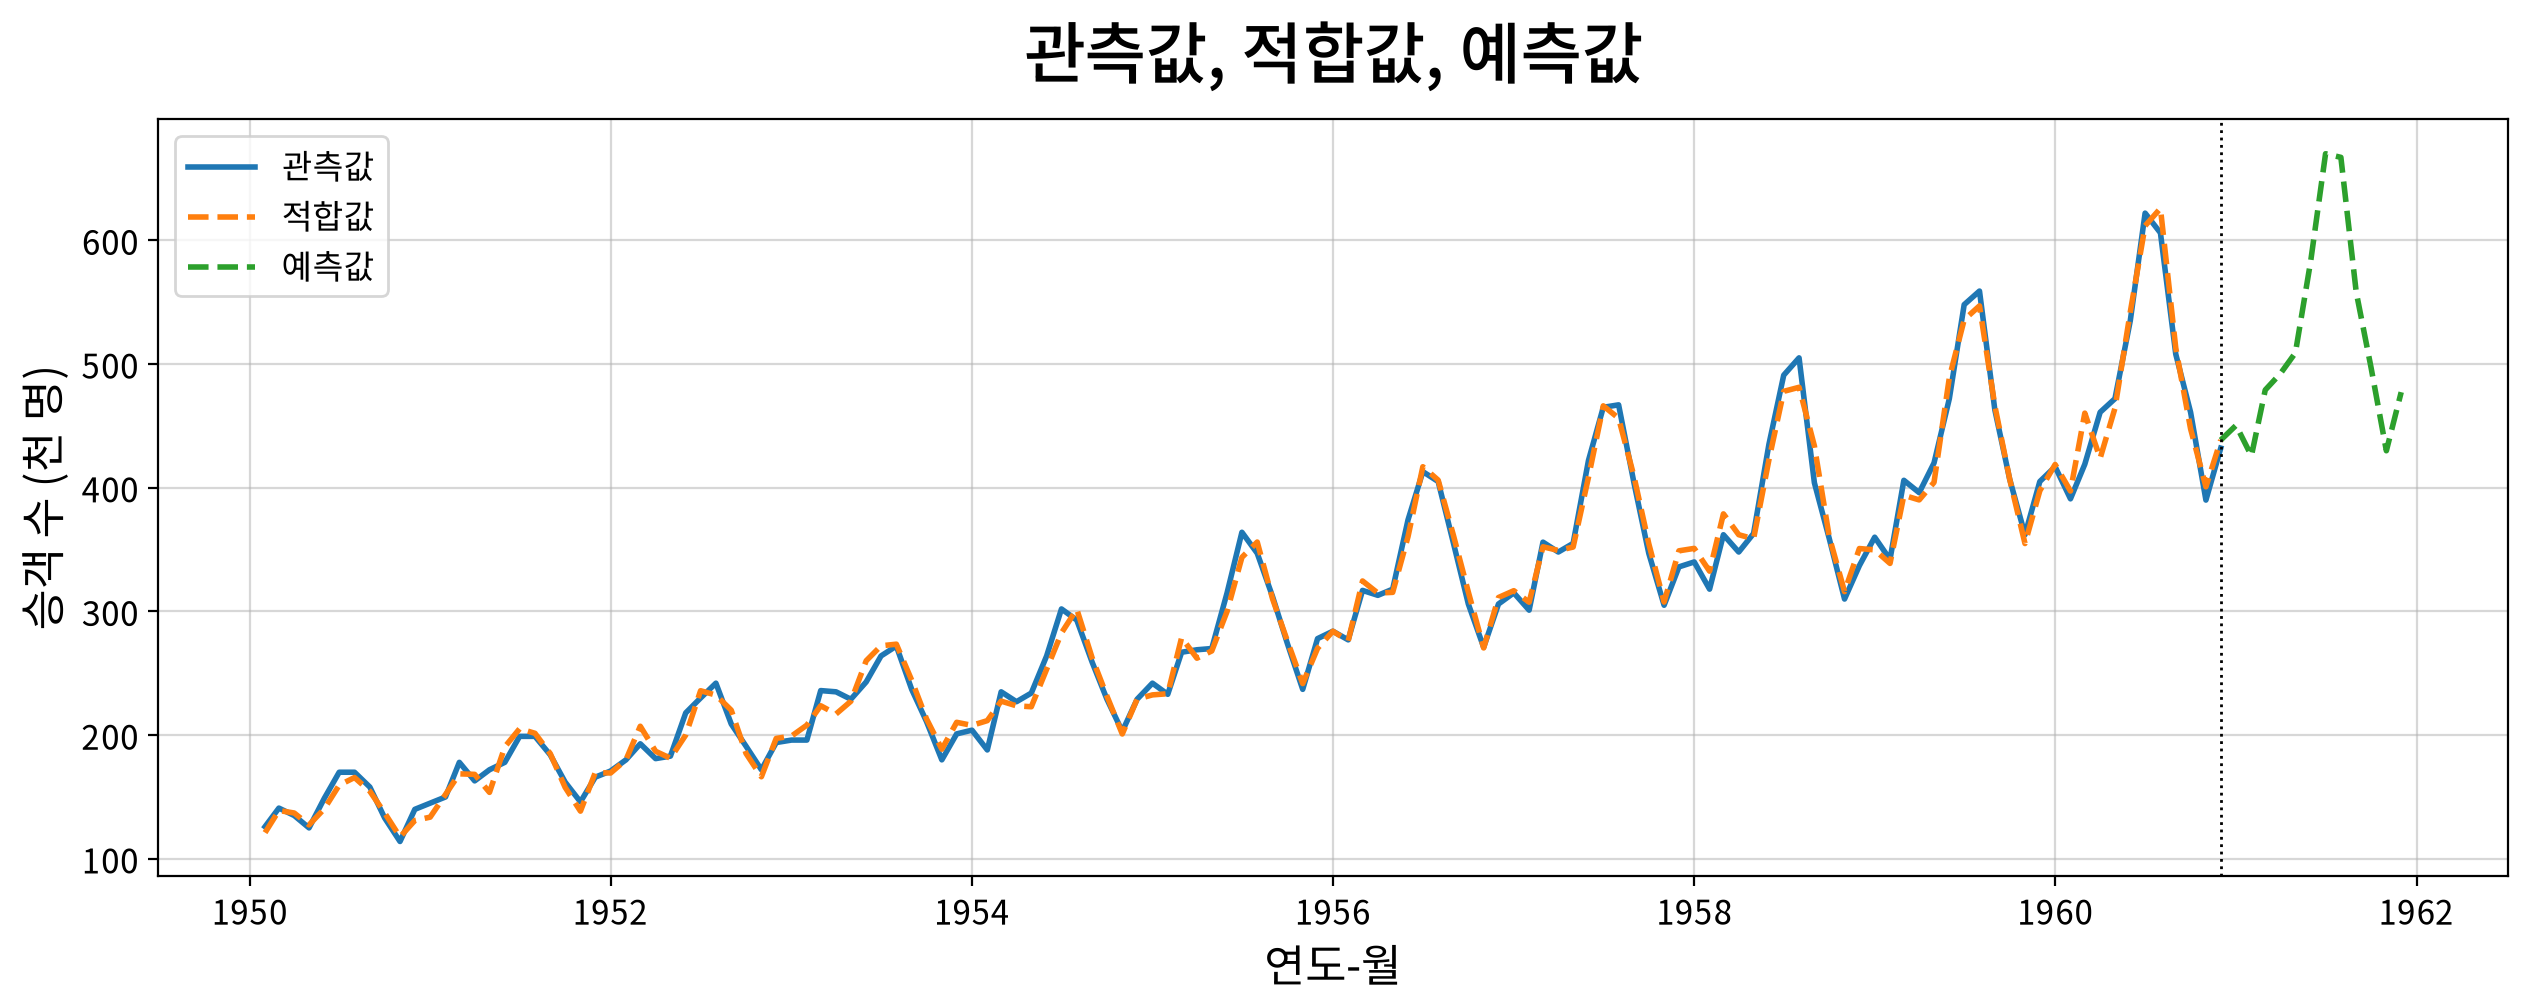

In [23]:
fig, ax = my_plot.init(width=1280, height=520, 
                       title="관측값, 적합값, 예측값", 
                       xlabel="연도-월", ylabel="승객 수 (천 명)")

# 적합 구간의 마지막 시점. 관측이 끝나고 예측이 시작되는 경계다 
last = df2["적합"].last_valid_index()

# 그대로 그리면 1960-12 (적합)와 1961-01(예측) 사이가 끊겨 보인다 
# 적합의 마지막 값을 예측선의 출발점으로 붙여 선을 이어준다 
predicted = df2["예측"].copy()
predicted[last] = df2.loc[last, "적합"] 

my_plot.lineplot(x=df2.index, y=df2["실제"].values, label="관측값", ax=ax)
my_plot.lineplot(x=df2.index, y=df2["적합"].values, label="적합값", linestyle="--", ax=ax)
my_plot.lineplot(x=df2.index, y=predicted.values, label="예측값",  linestyle="--", ax=ax)

# 경계 표시 : 이 선의 오른쪽은 실제 값이 존재하지 않는 구간이다 
ax.axvline(last, color="black", linestyle=":", linewidth=1) 

ax.legend()
my_plot.show()


# 2. 자기상관 판정 모듈화 

## #04. 모듈화 기능 확인
### 1. 차수 탐색 + 최적 모형 적합 

In [24]:
# 원본 데이터에서 다시 시작한다 
source = my_ts.set_index(origin, "Month", freq="MS")

best_fit = my_ts.fit_model(source,"Passengers", 
                           p=p, d=d, q=q, P=P, D=D, Q=Q, s=s, log=True)

시도한 조합 16가지 | 적합 성공 16가지 | 로그변환 적용
AIC 최적: (0, 1, 1)(0, 1, 1, 12) | BIC 최적: (0, 1, 1)(0, 1, 1, 12)


,모형,p,d,q,P,D,Q,s,계수 수,AIC,BIC
순위,,,,,,,,,,,
1,"(0, 1, 1)(0, 1, 1, 12)",0,1,1,0,1,1,12,3,-483.393,-474.767
2,"(0, 1, 1)(1, 1, 1, 12)",0,1,1,1,1,1,12,4,-481.906,-470.405
3,"(1, 1, 1)(0, 1, 1, 12)",1,1,1,0,1,1,12,4,-481.893,-470.392
4,"(1, 1, 0)(0, 1, 1, 12)",1,1,0,0,1,1,12,3,-481.484,-472.858
5,"(1, 1, 1)(1, 1, 1, 12)",1,1,1,1,1,1,12,5,-480.303,-465.927
6,"(1, 1, 0)(1, 1, 1, 12)",1,1,0,1,1,1,12,4,-479.723,-468.223
7,"(0, 1, 1)(1, 1, 0, 12)",0,1,1,1,1,0,12,3,-477.399,-468.773
8,"(1, 1, 1)(1, 1, 0, 12)",1,1,1,1,1,0,12,4,-475.459,-463.959
9,"(1, 1, 0)(1, 1, 0, 12)",1,1,0,1,1,0,12,3,-474.812,-466.187


### 2. 관측치 + 적합값 + 예측치 모출 및 시각화 

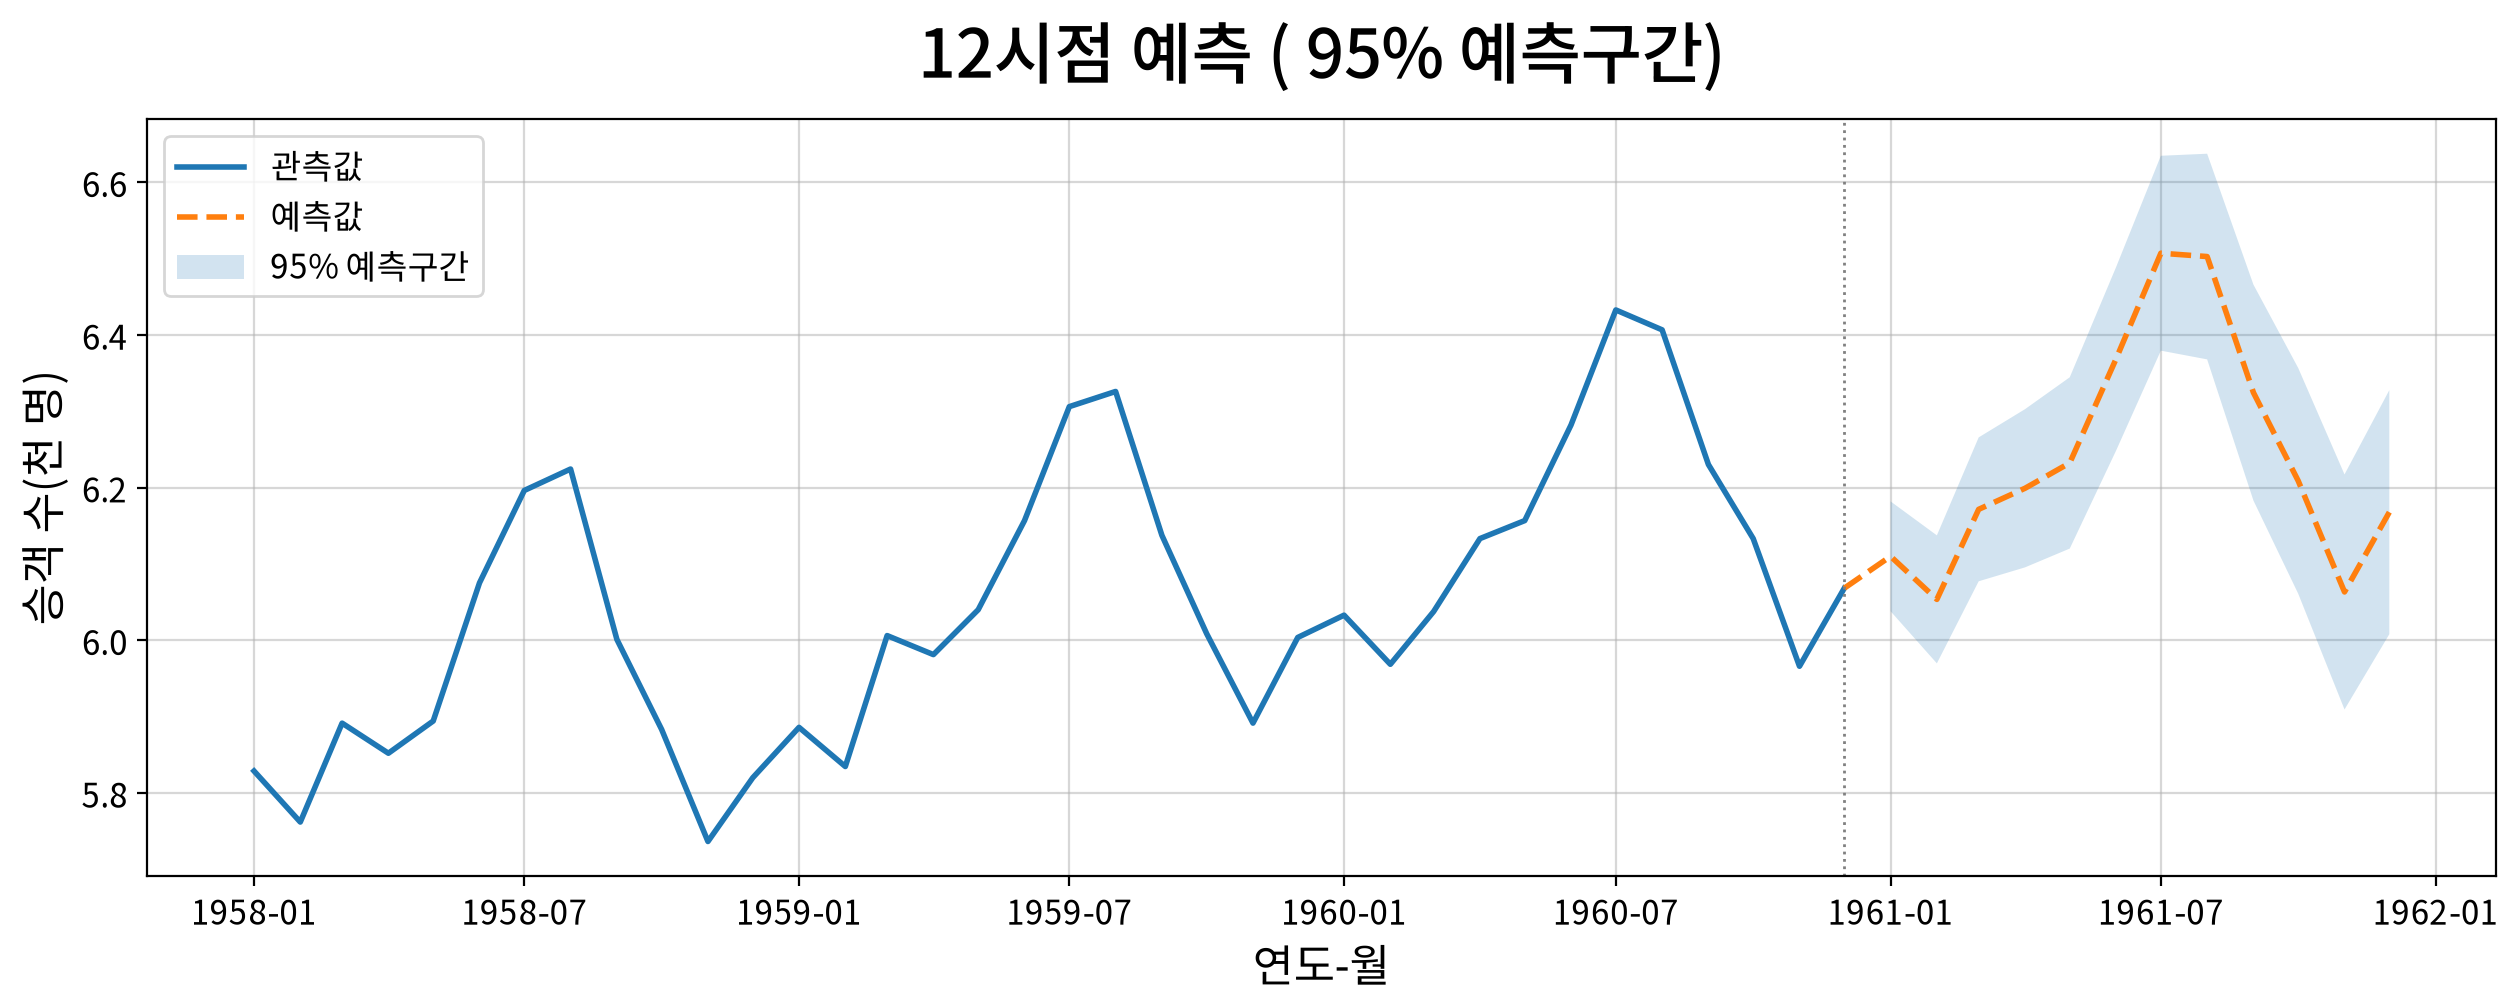

,pred,lower,upper
시점,,,
1961-01-01,6.110,6.038,6.182
1961-02-01,6.054,5.970,6.138
1961-03-01,6.172,6.077,6.266
1961-04-01,6.199,6.096,6.303
1961-05-01,6.233,6.120,6.345
1961-06-01,6.369,6.249,6.489
1961-07-01,6.507,6.380,6.635
1961-08-01,6.503,6.368,6.638
1961-09-01,6.325,6.183,6.466


In [25]:
my_ts.predict(best_fit, steps=s, history=36,
              xlabel="연도-월", ylabel="승객 수(천 명)")